
📊 Evaluation:

--- ANXIETY_CLASS ---
Accuracy: 0.98
[[ 32   3   0]
 [  1 107   0]
 [  0   0  57]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        35
           1       0.97      0.99      0.98       108
           2       1.00      1.00      1.00        57

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.98      0.98       200


--- DEPRESSION_CLASS ---
Accuracy: 0.965
[[ 28   5   0]
 [  1 116   0]
 [  0   1  49]]
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.95      0.99      0.97       117
           2       1.00      0.98      0.99        50

    accuracy                           0.96       200
   macro avg       0.97      0.94      0.95       200
weighted avg       0.97      0.96      0.96       200


--- STRESS_CLASS ---
Accuracy: 0.985
[[ 31   1   0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


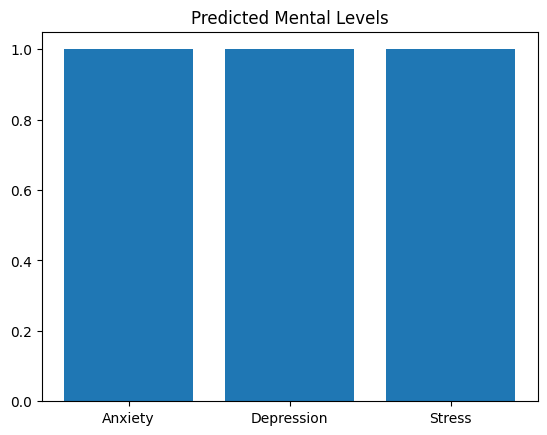

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("mental_health_dataset_1000.csv")


df["stress_level"] = (df["anxiety_level"] + df["depression_score"]) / 2


def to_class(x):
    if x < 3:
        return 0
    elif x < 6:
        return 1
    else:
        return 2

df["anxiety_class"] = df["anxiety_level"].apply(to_class)
df["depression_class"] = df["depression_score"].apply(to_class)
df["stress_class"] = df["stress_level"].apply(to_class)


X = df[[
    "age", "gender", "screen_time_hours",
    "social_media_hours", "entertainment_hours",
    "study_hours", "sleep_hours"
]]

y = df[["anxiety_class", "depression_class", "stress_class"]]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pickle.dump(scaler, open("scaler.pkl", "wb"))


model = LogisticRegression(max_iter=1000)


models = {}

for col in y.columns:
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train[col])
    models[col] = lr


pickle.dump(models, open("logistic_models.pkl", "wb"))


print("\n📊 Evaluation:")

for col in y.columns:
    y_pred = models[col].predict(X_test)
    print(f"\n--- {col.upper()} ---")
    print("Accuracy:", accuracy_score(y_test[col], y_pred))
    print(confusion_matrix(y_test[col], y_pred))
    print(classification_report(y_test[col], y_pred))



sample = [[20, 1, 6, 3, 2, 5, 6]]
sample = scaler.transform(sample)

print("\n Sample Prediction:")

labels = ["Low", "Moderate", "High"]

for col in y.columns:
    pred = models[col].predict(sample)[0]
    print(f"{col}: {labels[pred]}")



values = []
for col in y.columns:
    pred = models[col].predict(sample)[0]
    values.append(pred)

plt.bar(["Anxiety", "Depression", "Stress"], values)
plt.title("Predicted Mental Levels")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>